In [2]:
library(Seurat)
library(ggplot2)

data_dir <- "/mnt/f/wslproject/"
cat("环境准备完成\n")

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


环境准备完成


In [3]:
df   <- read.csv(paste0(data_dir, "GSM5710228_GTE009_counts.csv.gz"),
                 row.names=1, check.names=FALSE)
meta <- read.csv(paste0(data_dir, "GSM5710228_GTE009_metadata.csv.gz"),
                 row.names=1, check.names=FALSE)

seurat_obj <- CreateSeuratObject(counts=df, meta.data=meta)
rm(df); gc()

cat(sprintf("读取完成：%d 细胞 × %d 基因\n",
            ncol(seurat_obj), nrow(seurat_obj)))

Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3645437,194.7,5413601,289.2,5413601,289.2
Vcells,57812836,441.1,428909131,3272.4,503046944,3838.0


读取完成：10533 细胞 × 20314 基因


In [4]:
seurat_obj[["pct_mt"]] <- PercentageFeatureSet(seurat_obj, pattern="^MT-")
seurat_obj <- subset(seurat_obj,
                     subset = nFeature_RNA > 1500 & pct_mt < 12)
cat(sprintf("QC 后：%d 细胞\n", ncol(seurat_obj)))

QC 后：10531 细胞


In [5]:
seurat_obj <- NormalizeData(seurat_obj, normalization.method="LogNormalize",
                            scale.factor=10000)
seurat_obj <- FindVariableFeatures(seurat_obj, nfeatures=5000)
cat(sprintf("高变基因数量：%d\n", length(VariableFeatures(seurat_obj))))

Normalizing layer: counts

Finding variable features for layer counts



高变基因数量：5000


In [6]:
seurat_obj <- ScaleData(seurat_obj)
seurat_obj <- RunPCA(seurat_obj, npcs=50)
seurat_obj <- FindNeighbors(seurat_obj, dims=1:50)
seurat_obj <- FindClusters(seurat_obj, resolution=0.5)
seurat_obj <- RunUMAP(seurat_obj, dims=1:50, seed.use=42)
cat(sprintf("聚类完成！共识别 %d 个群落\n",
            length(unique(seurat_obj$seurat_clusters))))

Centering and scaling data matrix

PC_ 1 
Positive:  TYROBP, SRGN, C1QB, FTL, C1QA, APOE, LAPTM5, AIF1, C1QC, A2M 
	   FCER1G, CD68, GPR183, C3, MS4A7, RNASET2, APOC1, IER3, GPX1, CD74 
	   CD83, FCGRT, CYBA, CTSS, REL, PLAUR, FTH1, ITGB2, CYBB, TMSB4X 
Negative:  CLU, CKB, NTRK2, TUBA1A, SOX2, GPM6B, TUBB2B, NFIB, PTN, RBP1 
	   NFIX, GPM6A, CPE, METRN, TNC, NFIA, CSRP2, TPPP3, AQP4, PSAT1 
	   SPARCL1, RNF43, HES6, FZD3, MARCKSL1, PHGDH, MDK, IGF2, ZIC1, ACTG1 
PC_ 2 
Positive:  APOD, OLIG1, PLLP, TNR, SCRG1, PMP2, SEMA5A, ITM2A, OLIG2, GRIA2 
	   PDGFRA, STMN4, LHFPL3, NRXN1, CA10, MT3, PCDH17, LRRC4C, FGF12, LPPR1 
	   TTC9B, SOX10, C8orf46, THY1, BCHE, SLC1A2, CADM2, GAP43, C1QL1, SULF2 
Negative:  ANXA1, PLTP, AQP4, TNC, VIM, AP1S2, CSRP2, IGF2, TPPP3, GMPR 
	   NEAT1, TMEM47, RNF43, TCTEX1D1, C1orf192, C2orf40, LRRIQ1, C9orf24, MGST1, SPAG6 
	   MLC1, AK1, ID4, PIFO, PGAM2, ITIH5, VIPR2, C1orf194, S100A10, RSPH1 
PC_ 3 
Positive:  MKI67, TOP2A, PBK, NUSAP1, PRC1, NUF2, BIRC5, CE

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 10531
Number of edges: 401246

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8828
Number of communities: 15
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
13:56:12 UMAP embedding parameters a = 0.9922 b = 1.112

13:56:12 Read 10531 rows and found 50 numeric columns

13:56:12 Using Annoy for neighbor search, n_neighbors = 30

13:56:12 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:56:12 Writing NN index file to temp file /tmp/RtmpY8yF7L/fileb754901a312

13:56:12 Searching Annoy index using 1 thread, search_k = 3000

13:56:14 Annoy recall = 100%

13:56:14 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

聚类完成！共识别 15 个群落


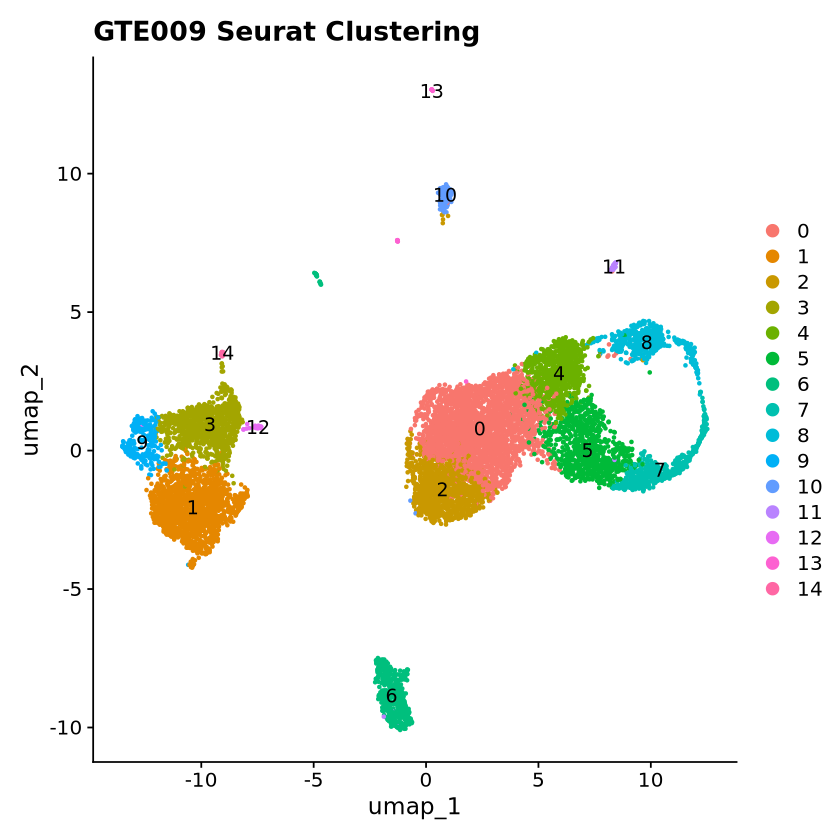

In [7]:
DimPlot(seurat_obj, reduction="umap",
        label=TRUE, pt.size=0.5) +
  ggtitle("GTE009 Seurat Clustering")

In [8]:
cell_markers <- list(
  "NSC-like"  = c("SOX2","NES","VIM","FABP7","HOPX"),
  "EpC-like"  = c("FOXJ1","PIFO","DNAH9","SPEF1","DYNC2H1"),
  "RGC-like"  = c("PTPRZ1","CLU","ALDOC"),
  "OPC-like"  = c("PDGFRA","CSPG4","OLIG1"),
  "OD-like"   = c("MBP","MOG","PLP1"),
  "NEU-like"  = c("RBFOX3","SYT1","SNAP25"),
  "AS-like"   = c("GFAP","AQP4","S100B"),
  "Mic"       = c("CX3CR1","P2RY12","CD68"),
  "EC"        = c("PECAM1","VWF","CDH5"),
  "TC"        = c("CD3D","CD3E","CD8A")
)

seurat_obj <- AddModuleScore(seurat_obj,
                             features=cell_markers,
                             name="score_")

score_cols <- paste0("score_", 1:length(cell_markers))
cell_type_names <- names(cell_markers)

seurat_obj$cell_type <- cell_type_names[
  apply(seurat_obj@meta.data[, score_cols], 1, which.max)
]

table(seurat_obj$cell_type)

Warning message:
“The following features are not present in the object: PECAM1, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: CD3D, CD3E, not searching for symbol synonyms”



 AS-like       EC EpC-like      Mic NEU-like NSC-like  OD-like OPC-like 
    1808       25      172     2631       20     1574      226      487 
RGC-like       TC 
    3574       14 

In [9]:
nsc_genes <- list(c("FTL","LGALS1","MEG3","MEST","TUBB","TMSB4X","STMN1"))
epc_genes <- list(c("FOXJ1","PIFO","DYNC2H1","DNAH9","SPEF1","ZMYND10"))

seurat_obj <- AddModuleScore(seurat_obj, features=nsc_genes, name="nsc_score")
seurat_obj <- AddModuleScore(seurat_obj, features=epc_genes, name="epc_score")

seurat_obj$trajectory_score <- seurat_obj$nsc_score1 - seurat_obj$epc_score1

cat("轨迹评分计算完成！\n")
summary(seurat_obj$trajectory_score)

轨迹评分计算完成！


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.89729 -0.09482  0.43057  0.41681  0.97954  2.14250 

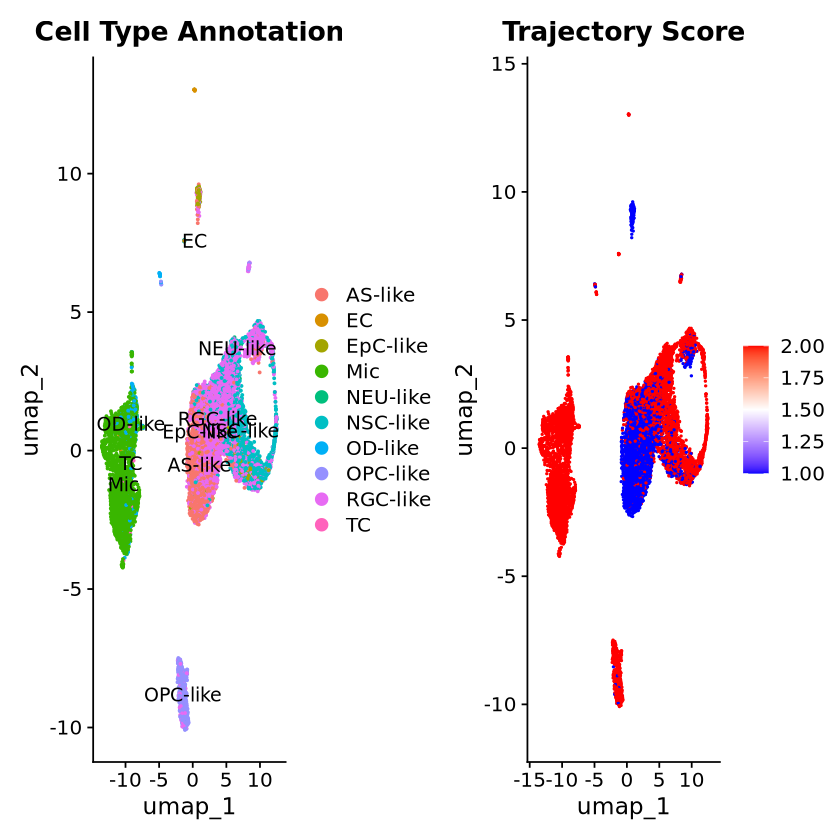

In [10]:
p1 <- DimPlot(seurat_obj, group.by="cell_type",
              label=TRUE, pt.size=0.3) +
      ggtitle("Cell Type Annotation")

p2 <- FeaturePlot(seurat_obj, features="trajectory_score",
                  cols=c("blue","white","red")) +
      ggtitle("Trajectory Score")

p1 | p2

In [11]:
saveRDS(seurat_obj, file=paste0(data_dir, "GTE009_seurat.rds"))
cat("已保存\n")

已保存


In [ ]:
# ====== 第六步：安装 inferCNV ======
# inferCNV 用来从 RNA 表达推断拷贝数变异(CNV)
# 从而区分恶性细胞 vs 正常细胞，并识别肿瘤内亚克隆

if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cloud.r-project.org")

if (!requireNamespace("infercnv", quietly=TRUE))
    BiocManager::install("infercnv", ask=FALSE, update=FALSE)

library(infercnv)
cat("inferCNV 加载完成\n")

In [ ]:
# ====== 第七步：准备 inferCNV 输入 ======
# inferCNV 需要三张"表"：
#   表A：原始计数矩阵（基因×细胞）—— 从 seurat_obj 提取
#   表B：细胞注释文件 —— 每个细胞属于哪个类型（用 cell_type 列）
#   表C：基因染色体位置文件 —— 每个基因在哪条染色体的哪个位置

# --- 表A：计数矩阵（已在 seurat_obj 里） ---
counts_matrix <- GetAssayData(seurat_obj, slot="counts")
cat(sprintf("计数矩阵：%d 基因 × %d 细胞\n", nrow(counts_matrix), ncol(counts_matrix)))

# --- 表B：细胞注释 ---
# | 细胞名   | 类型      |
# |----------|----------|
# | Cell_001 | NSC-like |
# | Cell_002 | Mic      |  ← 这些将作为"正常参考"
cell_annot <- data.frame(cell_type = seurat_obj$cell_type,
                         row.names = colnames(seurat_obj))
annot_file <- paste0(data_dir, "infercnv_annot.txt")
write.table(cell_annot, file=annot_file, sep="\t",
            col.names=FALSE, quote=FALSE)

# --- 表C：基因位置文件 ---
# 需要从 BioMart 或手动获取每个基因的 chr, start, end
# | 基因名 | 染色体 | 起始位置 | 终止位置 |
# |--------|--------|---------|---------|
# | SOX2   | chr3   | 181711925 | 181714436 |
if (!requireNamespace("biomaRt", quietly=TRUE))
    BiocManager::install("biomaRt", ask=FALSE, update=FALSE)

library(biomaRt)
ensembl <- useMart("ensembl", dataset="hsapiens_gene_ensembl")
gene_info <- getBM(attributes=c("hgnc_symbol","chromosome_name",
                                "start_position","end_position"),
                   filters="hgnc_symbol",
                   values=rownames(counts_matrix),
                   mart=ensembl)

# 只保留标准染色体(1-22, X, Y)
valid_chr <- c(as.character(1:22), "X", "Y")
gene_info <- gene_info[gene_info$chromosome_name %in% valid_chr, ]
gene_info <- gene_info[!duplicated(gene_info$hgnc_symbol), ]
gene_info <- gene_info[gene_info$hgnc_symbol != "", ]

# 按染色体和位置排序
gene_info$chromosome_name <- factor(gene_info$chromosome_name, levels=valid_chr)
gene_info <- gene_info[order(gene_info$chromosome_name, gene_info$start_position), ]

# 写入文件
gene_order <- gene_info[, c("hgnc_symbol","chromosome_name",
                            "start_position","end_position")]
gene_order_file <- paste0(data_dir, "gene_order.txt")
write.table(gene_order, file=gene_order_file, sep="\t",
            row.names=FALSE, col.names=FALSE, quote=FALSE)

cat(sprintf("基因位置文件：%d 个基因有染色体坐标\n", nrow(gene_order)))
cat("三张输入表准备完成！\n")

In [ ]:
# ====== 第八步：运行 inferCNV ======
# 论文方法："300 cells of OPCs were sampled from GTE009 as a common reference"
# 参考细胞 = 正常免疫/内皮细胞（Mic, TC, EC），它们是非恶性的
# inferCNV 通过对比"参考正常细胞"和"待测细胞"的基因表达差异来推断 CNV

# 想象一下：
# 如果某条染色体上连续几十个基因的表达都偏高 → 该区域可能被扩增了
# 如果连续几十个基因的表达都偏低 → 该区域可能被缺失了
# 正常细胞不会有这种成片的偏移

ref_group <- c("Mic", "TC", "EC")  # 非恶性细胞作为参考

infercnv_obj <- CreateInfercnvObject(
    raw_counts_matrix = counts_matrix,
    annotations_file  = annot_file,
    gene_order_file   = gene_order_file,
    ref_group_names   = ref_group,
    min_max_counts_per_cell = c(500, 6e6)
)

# 运行 inferCNV（这一步比较耗时，约 30-60 分钟）
infercnv_obj <- infercnv::run(
    infercnv_obj,
    cutoff   = 0.1,
    out_dir  = paste0(data_dir, "infercnv_output/"),
    cluster_by_groups   = TRUE,
    denoise  = TRUE,
    HMM      = FALSE,
    min_cells_per_gene  = 5,
    num_threads = 4
)

cat("inferCNV 运行完成！\n")

In [ ]:
# ====== 第九步：提取 CNV 评分 & 识别亚克隆 ======
# inferCNV 输出了一张大热图矩阵（行=细胞，列=按染色体排列的基因）
# 数值含义：1 = 正常拷贝，>1 = 扩增，<1 = 缺失

# 读取 inferCNV 结果矩阵
cnv_matrix <- as.matrix(read.table(
    paste0(data_dir, "infercnv_output/infercnv.observations.txt"),
    header=TRUE, row.names=1, check.names=FALSE
))

# 将 CNV 值重新标准化到 -1 ~ 1（1 为中心/正常）
cnv_scaled <- cnv_matrix - 1

# 计算每个细胞的 CNV 总分（所有基因 CNV 偏差的平方和）
# | 细胞     | CNV_score |
# |----------|-----------|
# | Cell_001 | 15.3      |  ← CNV 高 → 可能是恶性
# | Cell_002 | 0.8       |  ← CNV 低 → 可能是正常
cnv_score <- rowSums(cnv_scaled^2)

# 匹配回 Seurat 对象
common_cells <- intersect(names(cnv_score), colnames(seurat_obj))
seurat_obj$cnv_score <- NA
seurat_obj$cnv_score[match(common_cells, colnames(seurat_obj))] <- cnv_score[common_cells]

cat(sprintf("CNV 评分已计算，覆盖 %d 个细胞\n", length(common_cells)))

# --- 亚克隆识别 ---
# 对恶性细胞的 CNV 矩阵做层次聚类，分成 2 个亚克隆
# 论文方法：ward.D2 层次聚类

# 筛选非参考细胞（恶性细胞）
mal_cells <- colnames(seurat_obj)[!seurat_obj$cell_type %in% c("Mic","TC","EC")]
mal_cells_in_cnv <- intersect(mal_cells, rownames(cnv_matrix))

# 层次聚类
hc <- hclust(dist(cnv_matrix[mal_cells_in_cnv, ]), method="ward.D2")
subclone_labels <- cutree(hc, k=2)

# 写入 Seurat 对象
# | 细胞     | subclone |
# |----------|----------|
# | Cell_001 | 1        |
# | Cell_004 | 2        |
# | Cell_002 | NM       |  ← 非恶性细胞标记为 NM
seurat_obj$subclone <- "NM"
seurat_obj$subclone[match(names(subclone_labels), colnames(seurat_obj))] <- 
    paste0("Subclone_", subclone_labels)

table(seurat_obj$subclone)
cat("亚克隆识别完成！\n")

In [ ]:
# ====== 第十步：可视化 CNV 和亚克隆 ======
# 对应论文 Figure 1A, 1D

library(patchwork)

# 图1：CNV 评分在 UMAP 上的分布（对应 Fig 1A）
p_cnv <- FeaturePlot(seurat_obj, features="cnv_score",
                     cols=c("grey90","firebrick")) +
         ggtitle("CNV Score (Fig 1A)")

# 图2：亚克隆在 UMAP 上的分布（对应 Fig 1D）
p_sub <- DimPlot(seurat_obj, group.by="subclone",
                 cols=c("NM"="grey80","Subclone_1"="#E64B35",
                        "Subclone_2"="#4DBBD5"),
                 pt.size=0.3) +
         ggtitle("Subclonal Populations (Fig 1D)")

# 图3：细胞类型 × 亚克隆的组成（对应 Fig 1G）
# 统计每个亚克隆中各细胞类型的比例
p_cnv | p_sub

In [ ]:
# ====== 第十一步：亚克隆间细胞组成分析 (Fig 1G) ======
# 论文发现：亚克隆1中 NSC-like 比例更低，EpC-like 比例更高

# 只看恶性细胞的亚克隆
mal_data <- seurat_obj@meta.data[seurat_obj$subclone != "NM", ]

# 统计表：
# | subclone    | NSC-like | EpC-like | OPC-like | ... |
# |-------------|----------|----------|----------|-----|
# | Subclone_1  |   120    |   280    |    45    | ... |
# | Subclone_2  |   350    |    90    |    60    | ... |
comp_table <- table(mal_data$subclone, mal_data$cell_type)
comp_pct   <- prop.table(comp_table, margin=1) * 100

cat("亚克隆细胞组成(%)：\n")
print(round(comp_pct, 1))

# 柱状图可视化
library(tidyr)
library(dplyr)

comp_df <- as.data.frame(comp_pct)
colnames(comp_df) <- c("Subclone", "CellType", "Percentage")

ggplot(comp_df, aes(x=Subclone, y=Percentage, fill=CellType)) +
    geom_bar(stat="identity", position="stack") +
    theme_minimal() +
    ggtitle("Cell Type Composition by Subclone (Fig 1G)") +
    ylab("Percentage (%)") +
    theme(axis.text.x = element_text(angle=45, hjust=1))

In [ ]:
# ====== 第十二步：亚克隆间差异基因 + GO 分析 (Fig 1H-I) ======
# 论文发现：亚克隆1 vs 亚克隆2 的差异基因富集在纤毛(cilium)相关通路

if (!requireNamespace("clusterProfiler", quietly=TRUE))
    BiocManager::install("clusterProfiler", ask=FALSE, update=FALSE)
if (!requireNamespace("org.Hs.eg.db", quietly=TRUE))
    BiocManager::install("org.Hs.eg.db", ask=FALSE, update=FALSE)

library(clusterProfiler)
library(org.Hs.eg.db)

# 设置 Ident 为亚克隆标签，只比较恶性细胞
mal_obj <- subset(seurat_obj, subclone != "NM")
Idents(mal_obj) <- "subclone"

# 找差异基因：Subclone_1 vs Subclone_2
# 结果是一张表：
# | 基因    | avg_log2FC | p_val_adj | 在哪个亚克隆高表达 |
# |---------|-----------|-----------|------------------|
# | FOXJ1   | +1.2      | 1e-20     | Subclone_1 ↑     |
# | STMN1   | -0.8      | 3e-15     | Subclone_2 ↑     |
deg_subclone <- FindMarkers(mal_obj, ident.1="Subclone_1", ident.2="Subclone_2",
                            min.pct=0.1, logfc.threshold=0.25)

cat(sprintf("亚克隆间差异基因：%d 个\n", nrow(deg_subclone)))

# 取亚克隆1上调的基因做 GO 分析
up_genes <- rownames(deg_subclone[deg_subclone$avg_log2FC > 0 & 
                                   deg_subclone$p_val_adj < 0.05, ])

go_result <- enrichGO(gene     = up_genes,
                      OrgDb    = org.Hs.eg.db,
                      keyType  = "SYMBOL",
                      ont      = "BP",
                      pAdjustMethod = "BH",
                      pvalueCutoff  = 0.05)

# 展示前15个通路（论文中看到的纤毛相关通路应在其中）
dotplot(go_result, showCategory=15) +
    ggtitle("GO: Subclone 1 upregulated genes (Fig 1I)")

In [ ]:
# ====== 第十三步：保存更新后的 Seurat 对象 ======
saveRDS(seurat_obj, file=paste0(data_dir, "GTE009_seurat_cnv.rds"))
cat("已保存（含 CNV + 亚克隆信息）\n")